# Social Enterprise Analysis

In [ ]:
import pandas as pd
import json
from pathlib import Path


df = pd.read_csv("Data/datadotgov_ais23_cleaned.csv")

## What's a social enterprise?

In [24]:
import numpy as np
from tabulate import tabulate

sizes = [1, 2, 3]
rows = []

for size in sizes:
    size_df = df[df['charity size'] == size]
    se_df = size_df[size_df['is_se'] == 1]
    se_pct = (len(se_df) / len(size_df) * 100) if len(size_df) > 0 else 0

    rows.append([
        size,
        f"{len(size_df):,}",
        f"{len(se_df):,}",
        f"{se_pct:.1f}%"
    ])

se_df = df[df['is_se'] == 1]
se_pct = (len(se_df) / len(df) * 100) if len(df) > 0 else 0

rows.append([
    'Total',
    f"{len(df):,}",
    f"{len(se_df):,}",
    f"{se_pct:.1f}%"
])

print(tabulate(
    rows,
    headers=['Size', 'Charities (SE and non-SE)', 'SEs', 'SE %'],
    tablefmt='grid',
    colalign=('left', 'right', 'right', 'right')
))

+--------+-----------------------------+--------+--------+
| Size   |   Charities (SE and non-SE) |    SEs |   SE % |
+========+=============================+========+========+
| 1      |                      39,537 |  6,716 |  17.0% |
+--------+-----------------------------+--------+--------+
| 2      |                       8,121 |  1,961 |  24.1% |
+--------+-----------------------------+--------+--------+
| 3      |                       5,627 |  1,524 |  27.1% |
+--------+-----------------------------+--------+--------+
| Total  |                      53,285 | 10,201 |  19.1% |
+--------+-----------------------------+--------+--------+


Definition chosen:
- Charities deriving at least 50% of revenue from earned income (goods and services)

Social enterprises (SEs):
- 10,201 charities qualify as SEs
- 19.1% of the whole sector

By size:
- Larger orgs are more likely to run as SEs
- There are many more small charities overall

## Size analysis

In [25]:
non_se_df = df[df['is_se'] == 0]

metrics = {
    'Avg total income ($)': 'total gross income',
    'Avg total expenses ($)': 'total expenses',
    'Avg assets ($)': 'total assets',
}

size_groups = [
    ('Small SE', se_df[se_df['charity size'] == 1]),
    ('Medium SE', se_df[se_df['charity size'] == 2]),
    ('Large SE', se_df[se_df['charity size'] == 3]),
    ('Overall SE', se_df),
    ('Small non-SE', non_se_df[non_se_df['charity size'] == 1]),
    ('Medium non-SE', non_se_df[non_se_df['charity size'] == 2]),
    ('Large non-SE', non_se_df[non_se_df['charity size'] == 3]),
    ('Overall non-SE', non_se_df),
]

rows = []

for group_label, group_df in size_groups:
    row = [group_label]
    for metric_label, col in metrics.items():
        value = group_df[col].sum() / len(group_df) if len(group_df) > 0 else 0
        row.append(f"${value:,.0f}")
    rows.append(row)
        
print(tabulate(
    rows,
    headers=['Group'] + list(metrics),
    tablefmt='grid',
    colalign=('left', 'right', 'right', 'right')
 ))

+----------------+------------------------+--------------------------+------------------+
| Group          |   Avg total income ($) |   Avg total expenses ($) |   Avg assets ($) |
+================+========================+==========================+==================+
| Small SE       |               $119,112 |                 $121,967 |         $806,282 |
+----------------+------------------------+--------------------------+------------------+
| Medium SE      |             $1,358,451 |               $2,753,284 |       $3,450,704 |
+----------------+------------------------+--------------------------+------------------+
| Large SE       |            $34,680,341 |              $33,566,939 |      $67,970,430 |
+----------------+------------------------+--------------------------+------------------+
| Overall SE     |             $5,520,706 |               $5,624,383 |      $11,348,765 |
+----------------+------------------------+--------------------------+------------------+
| Small no

Small charities:
- SEs bring in slightly more ($117k vs $85k) but spend more too ($122k vs $84k)
- Running lean with not much left over

Medium charities:
- SEs are in trouble: spending $2.75M but only making $1.34M
- They're either burning through savings or relying on external funding

Large charities:
- SEs doing better: $34.4M income, $33.5M expenses (nearly balanced)
- Pretty efficient operations at scale

Overall patterns:
- SEs hold bigger assets ($10.9M vs $8.9M for non-SEs)
- But they're also carrying more debt ($3.8M vs $3M)
- SEs borrow to reinvest and grow

Different strategies:
- SEs: Reinvesting money back into their work, higher risk
- Traditional charities: Playing it safe, lower risk

## Revenue sources

+----------------+--------------------+--------------+------------------------+---------------+---------+
| Group          |   Goods & services |   Government |   Donations & bequests |   Investments | Other   |
+================+====================+==============+========================+===============+=========+
| Small SE       |              82.3% |         5.7% |                   7.4% |          1.4% | 3.2%    |
+----------------+--------------------+--------------+------------------------+---------------+---------+
| Medium SE      |              81.5% |         9.7% |                   4.5% |          1.5% | 2.8%    |
+----------------+--------------------+--------------+------------------------+---------------+---------+
| Large SE       |              77.6% |        16.1% |                   1.7% |          2.0% | 2.7%    |
+----------------+--------------------+--------------+------------------------+---------------+---------+
| Overall SE     |              77.9% |       

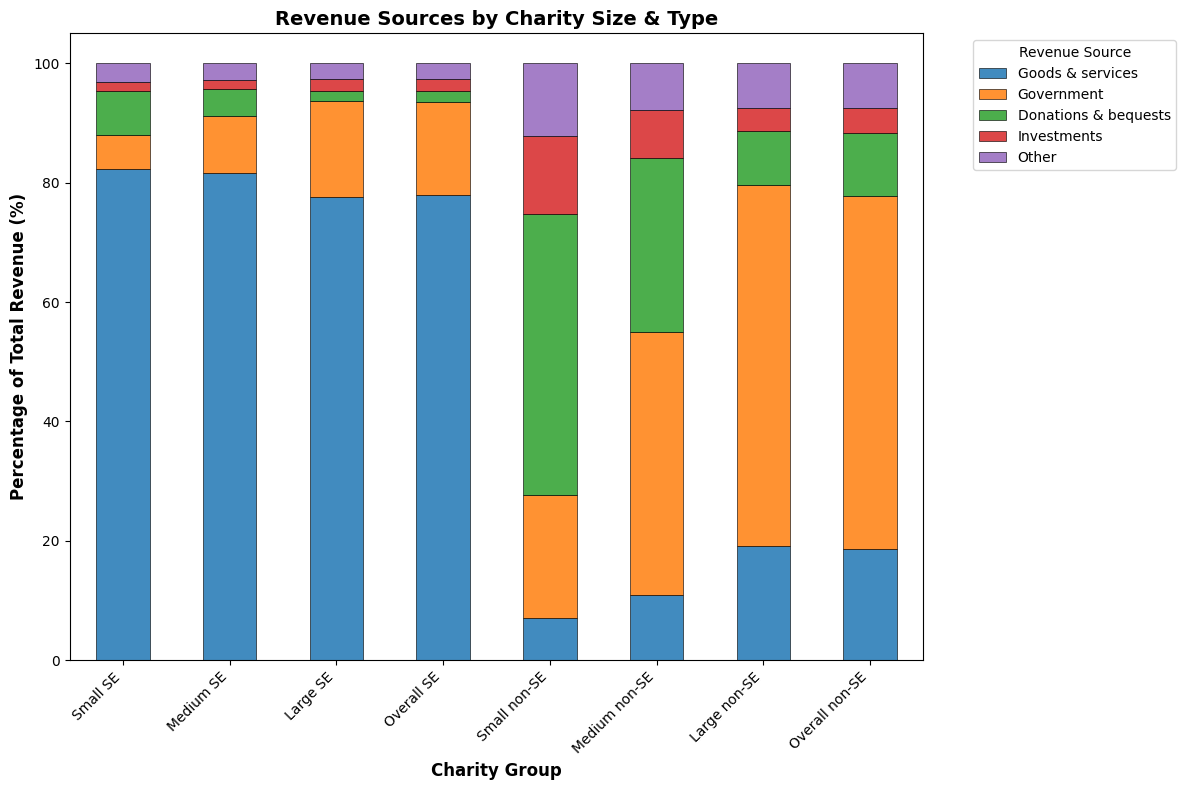

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from tabulate import tabulate

metrics = {
    'Goods & services': 'revenue from goods and services',
    'Government': 'revenue from government',
    'Donations & bequests': 'donations and bequests',
    'Investments': 'revenue from investments',
    'Other': 'all other revenue',
}

rows = []
chart_data = []

for group_label, group_df in size_groups:
    row = [group_label]
    chart_row = {'Group': group_label}
    for revenue_label, col in metrics.items():
        total_value = group_df[col].sum()
        total_revenue = group_df['total revenue'].sum()
        pct = (total_value / total_revenue * 100) if total_revenue > 0 else 0
        row.append(f"{pct:.1f}%")
        chart_row[revenue_label] = pct
    rows.append(row)
    chart_data.append(chart_row)
        
print(tabulate(
    rows,
    headers=['Group'] + list(metrics),
    tablefmt='grid',
    colalign=('left', 'right', 'right', 'right', 'right')
))

chart_df = pd.DataFrame(chart_data)

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("tab10", n_colors=len(metrics))

revenue_sources = list(metrics.keys())

chart_df.set_index('Group')[revenue_sources].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

ax.set_ylabel('Percentage of Total Revenue (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Charity Group', fontsize=12, fontweight='bold')
ax.set_title('Revenue Sources by Charity Size & Type',fontsize=14, fontweight='bold')
ax.legend(title='Revenue Source', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Goods & services:
- SEs dominate: 78-82% across all sizes
- Non-SEs: Only 7-19%

Government:
- SEs: 5-16% (not their main income)
- Non-SEs: 20-60% (major funding source)

Donations & Bequests:
- SEs: Only 1-7% (minimal reliance)
- Non-SEs: 9-47% (significant source)

Investments & other:
- Both groups: Around 1-4% each

Big picture:
- SEs: 78% commercial income = genuinely self-sustaining
- Non-SEs: 59% government + 10% donations = dependent funding
- Clear divide: SEs run like businesses, non-SEs run like traditional charities


## Staffing

+----------------+-----------------------+-----------------------+--------------------+------------------+-----------------+
| Group          |   Avg full time staff |   Avg part time staff |   Avg casual staff |   Avg volunteers |   Total Staff # |
+================+=======================+=======================+====================+==================+=================+
| Small SE       |                    0% |                    1% |                 3% |              95% |              36 |
+----------------+-----------------------+-----------------------+--------------------+------------------+-----------------+
| Medium SE      |                    3% |                    5% |                 7% |              85% |             110 |
+----------------+-----------------------+-----------------------+--------------------+------------------+-----------------+
| Large SE       |                   21% |                   18% |                17% |              44% |             431 |


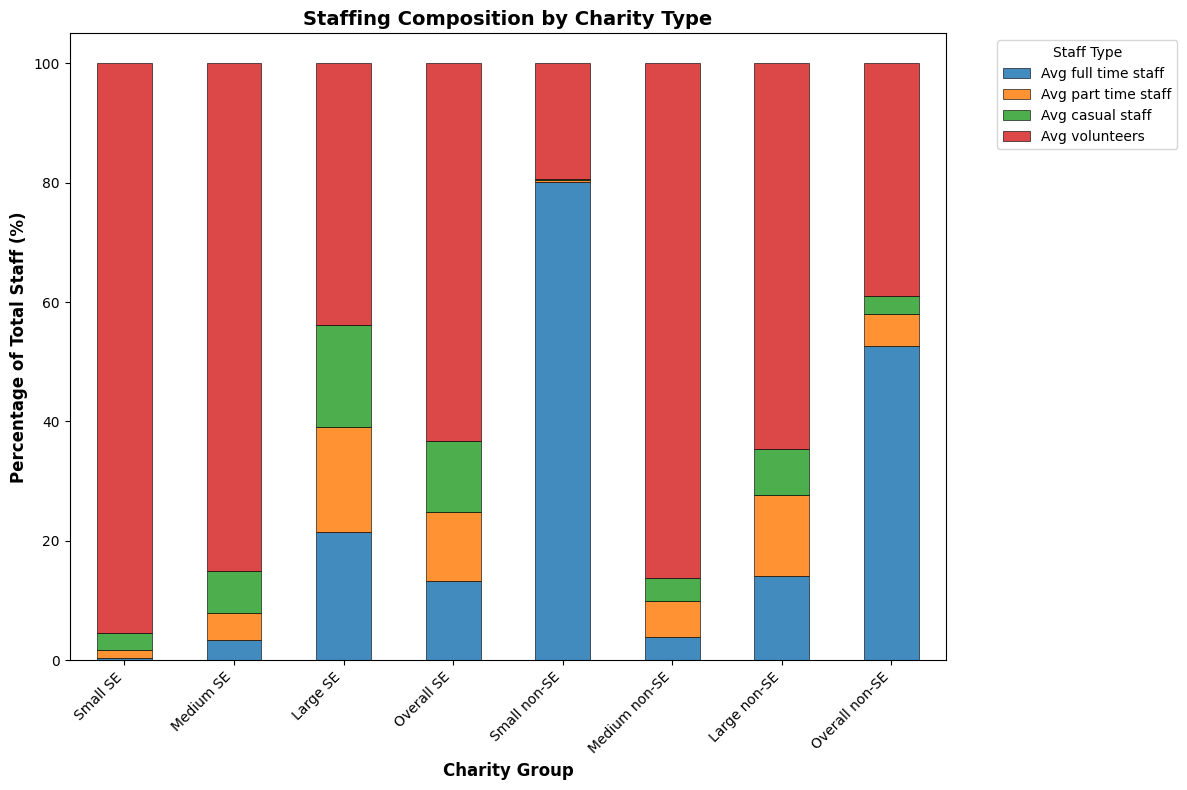

In [ ]:
metrics = {
    'Avg full time staff': 'staff - full time',
    'Avg part time staff': 'staff - part time',
    'Avg casual staff': 'staff - casual',
    'Avg volunteers': 'staff - volunteers',
}

rows = []
chart_data = []


for group_label, group_df in size_groups:
    staff_counts = {}
    total_staff = 0

    for label, col in metrics.items():
        count = group_df[col].sum() / len(group_df) if len(group_df) > 0 else 0
        staff_counts[label] = count
        total_staff += count
    
    row = [group_label]
    chart_row = {'Group': group_label}
    for label in metrics.keys():
        pct = (staff_counts[label] / total_staff * 100) if total_staff > 0 else 0
        row.append(f"{pct:.0f}%")
        chart_row[label] = pct
    row.append(f"{int(total_staff)}")
    rows.append(row)
    chart_data.append(chart_row)

print(tabulate(
    rows,
    headers=['Group'] + list(metrics)+ ['Total Staff #'],
    tablefmt='grid',
    colalign=('left', 'right', 'right', 'right', 'right')
))

chart_df = pd.DataFrame(chart_data)

fig, ax = plt.subplots(figsize=(12, 8))
palette = sns.color_palette("tab10", n_colors=len(metrics))

staff_types = list(metrics.keys())

chart_df.set_index('Group')[staff_types].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=palette,
    alpha=0.85,
    edgecolor='black',
    linewidth=0.5
)

ax.set_ylabel('Percentage of Total Staff (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Charity Group', fontsize=12, fontweight='bold')
ax.set_title('Staffing Composition by Charity Type', fontsize=14, fontweight='bold')
ax.legend(title='Staff Type', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Small charities:
- Run almost entirely on volunteers
- More diverse staffing but lower overall capacity

Medium charities:
- Growing volunteer base as operations expand
- Similar paid staff, slightly better overall capacity

Large charities:
- Substantial paid workforce + large volunteer army
- Similar paid capacity but WAY more volunteers (453 vs 188)

Overall pattern:
- SEs: Lean on mix of volunteers (70 avg) and casual/part-time workers
- Non-SEs: More full-time paid staff (101 vs 15), but similar volunteer numbers
- SEs are lean operators scaling with flexible workforce
- Non-SEs have institutional staffing with fewer part-timers

## Feature importance to income

In [28]:
from sklearn.ensemble import RandomForestRegressor

X = df.drop([
    'is_se',
    'total gross income',
    'total revenue',
    'revenue from goods and services',
    'revenue from government',
    'donations and bequests',
    'revenue from investments',
    'all other revenue',
    'total expenses',
    'all other expenses',
    'employee expenses',
    'net surplus/deficit',
    'total comprehensive income'
], axis=1)
y = df['total gross income']

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_,
    'Importance %': model.feature_importances_ * 100
}).sort_values('Importance', ascending=False)

rows = []
for idx, row in importance_df.head(10).iterrows():
    rows.append([
        row['Feature'],
        f"{row['Importance']:.4f}",
        f"{row['Importance %']:.2f}%"
    ])

print(tabulate(
    rows,
    headers=['Feature', 'Importance Score', 'Percentage'],
    tablefmt='grid',
    colalign=('left', 'right', 'right')
))

+----------------------------------+--------------------+--------------+
| Feature                          |   Importance Score |   Percentage |
+==================================+====================+==============+
| other non-current assets         |              0.362 |       36.20% |
+----------------------------------+--------------------+--------------+
| staff - full time                |             0.1817 |       18.17% |
+----------------------------------+--------------------+--------------+
| total non-current assets         |             0.1134 |       11.34% |
+----------------------------------+--------------------+--------------+
| total assets                     |             0.0874 |        8.74% |
+----------------------------------+--------------------+--------------+
| total current assets             |             0.0495 |        4.95% |
+----------------------------------+--------------------+--------------+
| total full time equivalent staff |             0.

Asset base is critical:
- Charities with more non-current assets (infrastructure) generate significantly more income

Staffing capacity:
- Organisations with larger permanent workforces produce higher revenue
- Casual staff have minimal impact

Current assets:
- Long-term assets matter more than liquid cash
- Suggests income generation depends on operational capacity, not balance sheeet liquidity